Found Dataset Classes: ['tin']



Analyzing test: 100%|██████████| 303/303 [00:00<00:00, 2367.12it/s]



DATASET METRICS & PERCENTAGE DISTRIBUTION
| Split   |   Images Count | Images %   |   Bounding Boxes | Boxes %   |
|:--------|---------------:|:-----------|-----------------:|:----------|
| train   |           1418 | 70.0%      |             1753 | 70.0%     |
| valid   |            304 | 15.0%      |              380 | 15.2%     |
| test    |            303 | 15.0%      |              372 | 14.9%     |

Total Dataset Images: 2025
Total Dataset Bounding Boxes: 2505



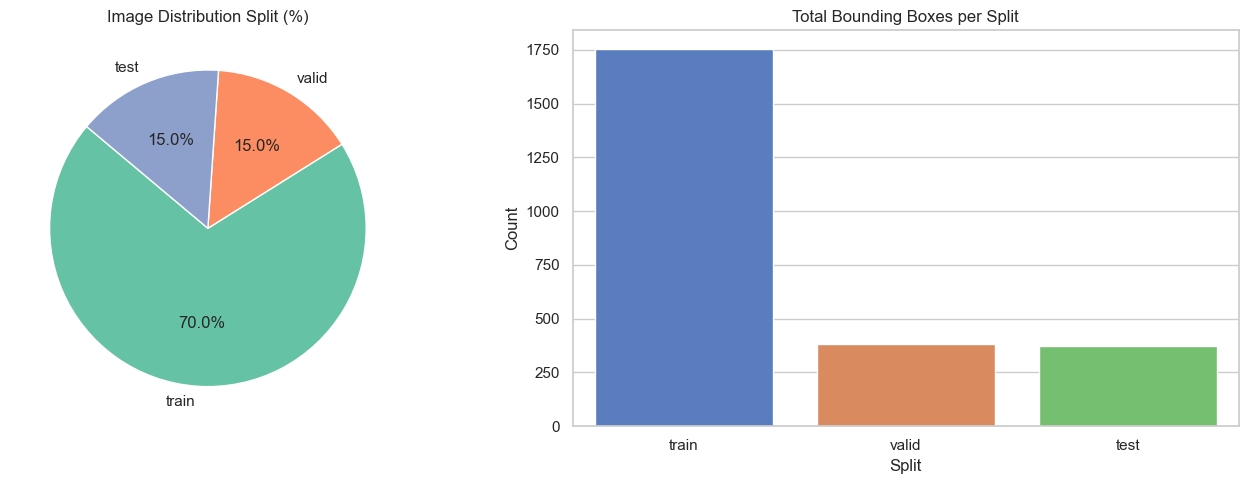

In [1]:
import os
import glob
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

def analyze_yolo_dataset_counts(dataset_dir):
    yaml_path = os.path.join(dataset_dir, "data.yaml")

    if not os.path.exists(yaml_path):
        raise FileNotFoundError(f"Could not find data.yaml at {yaml_path}. Check your path!")

    with open(yaml_path, 'r') as f:
        data_config = yaml.safe_load(f)

    class_names = data_config.get('names', [])
    print(f"Found Dataset Classes: {class_names}\n")

    def analyze_split(split_name):
        img_dir = os.path.join(dataset_dir, split_name, "images")
        lbl_dir = os.path.join(dataset_dir, split_name, "labels")
        
        if not os.path.exists(img_dir):
            return []
            
        img_files = glob.glob(os.path.join(img_dir, "*.*"))
        records = []
        
        for img_path in tqdm(img_files, desc=f"Analyzing {split_name}"):
            base_name = os.path.splitext(os.path.basename(img_path))[0]
            lbl_path = os.path.join(lbl_dir, f"{base_name}.txt")
            
            box_count = 0
            if os.path.exists(lbl_path):
                with open(lbl_path, 'r') as f:
                    lines = f.readlines()
                    for line in lines:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            records.append({
                                "Split": split_name,
                                "Image": base_name,
                                "Is_Object": 1
                            })
                            box_count += 1
                            
            if box_count == 0:
                records.append({
                    "Split": split_name,
                    "Image": base_name,
                    "Is_Object": 0
                })
                
        return records

    all_data = []
    for split in ["train", "valid", "test"]:
        all_data.extend(analyze_split(split))

    if not all_data:
        print("No data found to analyze.")
        return

    df = pd.DataFrame(all_data)
    unique_imgs = df.drop_duplicates(subset=["Split", "Image"])

    total_images_all = len(unique_imgs)
    total_boxes_all = len(df[df["Is_Object"] == 1])

    print("\n==========================================================")
    print("DATASET METRICS & PERCENTAGE DISTRIBUTION")
    print("==========================================================")
    
    splits_found = ["train", "valid", "test"]
    summary_data = []
    
    for split in splits_found:
        split_imgs = unique_imgs[unique_imgs["Split"] == split]
        split_boxes = df[(df["Split"] == split) & (df["Is_Object"] == 1)]
        
        img_count = len(split_imgs)
        box_count = len(split_boxes)
        
        img_pct = (img_count / total_images_all) * 100 if total_images_all > 0 else 0
        box_pct = (box_count / total_boxes_all) * 100 if total_boxes_all > 0 else 0
        
        summary_data.append({
            "Split": split,
            "Images Count": img_count,
            "Images %": f"{img_pct:.1f}%",
            "Bounding Boxes": box_count,
            "Boxes %": f"{box_pct:.1f}%"
        })
        
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_markdown(index=False))
    print(f"\nTotal Dataset Images: {total_images_all}")
    print(f"Total Dataset Bounding Boxes: {total_boxes_all}")
    print("==========================================================\n")

    # --- PLOT SIMPLIFIED DISTRIBUTION ---
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Graph 1: Image Split Breakdown
    img_counts_series = unique_imgs["Split"].value_counts().reindex(splits_found, fill_value=0)
    if img_counts_series.sum() > 0:
        axes[0].pie(img_counts_series, labels=img_counts_series.index, autopct='%1.1f%%', 
                    startangle=140, colors=sns.color_palette("Set2", len(img_counts_series)))
        axes[0].set_title("Image Distribution Split (%)")
    else:
        axes[0].text(0.5, 0.5, "No images found", ha='center')

    # Graph 2: Total Bounding Box counts per split
    instances_df = df[df["Is_Object"] == 1]
    if not instances_df.empty:
        sns.countplot(data=instances_df, x="Split", hue="Split", order=splits_found, ax=axes[1], palette="muted", legend=False)
        axes[1].set_title("Total Bounding Boxes per Split")
        axes[1].set_ylabel("Count")
        axes[1].set_xlabel("Split")
    else:
        axes[1].text(0.5, 0.5, "No bounding boxes found", ha='center')

    plt.tight_layout()
    plt.show()
    
analyze_yolo_dataset_counts("../data/tin")